In [45]:
import torch
import torch.nn as nn
import math


class ExplainableLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ExplainableLSTM, self).__init__()
        self.hidden_size = hidden_size

        # 1. 定义权重层
        # LSTM 内部其实就是线性变换，只是会有 4 倍的 hidden_size
        # 因为要同时计算：输入门、遗忘门、细胞候选、输出门 (4个部分)
        # ih 表示 input-hidden, hh 表示 hidden-hidden weights表示对应权重
        self.weight_ih = nn.Linear(input_size, 4 * hidden_size)  # 处理输入 x ih表示 input-hidden (从当前输入到隐层）
        self.weight_hh = nn.Linear(hidden_size, 4 * hidden_size)  # 处理上一步的隐状态 h hh表示 hidden-hidden (从上一个隐层到当前隐层）    
        # print(f'self.weight_ih 初始值: {self.weight_ih}')
        # print(f'self.weight_hh 初始值: {self.weight_hh}')
        # 最后的全连接层
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        batch_size, seq_len, _ = x.size()

        # 初始化 h0, c0 (隐状态和细胞状态)
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)  #h_t 表示隐状态 
        c_t = torch.zeros(batch_size, self.hidden_size).to(x.device)  #c_t 表示细胞状态
        # print(f'初始隐状态 h_t 形状: {h_t.shape}')
        # print(f'初始细胞状态 c_t 形状: {c_t.shape}')
        # print(f'cell state c_t 初始值: {c_t}')
        # print(f'hidden state h_t 初始值: {h_t}')
        # === 核心差异：我们需要手动循环时间步 ===
        for t in range(seq_len):
            x_t = x[:, t, :]  # 取出当前时刻的输入
            # print(f'时间步 {t} 的输入 x_t 形状: {x_t.shape}')
            # 2. 计算门控所需的原始值 (Gates Pre-activation)
            # 公式：W_ih * x_t + W_hh * h_{t-1} + bias
            # print(f'self.weight_ih(x_t)为{self.weight_ih(x_t)}')
            # print(f'self.weight_hh(h_t)为{self.weight_hh(h_t)}')
            gates = self.weight_ih(x_t) + self.weight_hh(h_t)  #计算当前时间步的 gates 向量 其中gates表示所有门的原始值，这里采用矩阵计算
            # print(f'时间步 {t} 的 gates 形状: {gates.shape}')
            # print(f'时间步 {t} 的 gates 值: {gates}')
            # gates 形状: (batch_size, 4 * hidden_size)   
            # 3. 将巨大的 gates 向量切分成 4 份
            # 每一份对应一个特定的功能门
            # chunks 的顺序通常是：输入门(i), 遗忘门(f), 细胞候选(g), 输出门(o)
            i_raw, f_raw, g_raw, o_raw = gates.chunk(4, 1)
            # 4. 计算各个门的激活值
            # 遗忘门 (Forget Gate): 决定丢弃多少旧记忆 c_{t-1}
            f_t = torch.sigmoid(f_raw)

            # 输入门 (Input Gate): 决定接纳多少新信息
            i_t = torch.sigmoid(i_raw)

            # 候选记忆 (Cell Candidate): 当前时刻提取的新特征
            g_t = torch.tanh(g_raw)

            # 输出门 (Output Gate): 决定输出多少信息给 h_t
            o_t = torch.sigmoid(o_raw)

            # === 状态更新 ===

            # 更新细胞状态 Cell State (核心公式)
            # 新记忆 = (旧记忆 × 遗忘比例) + (新特征 × 输入比例)
            c_t = c_t * f_t + g_t * i_t

            # 更新隐状态 Hidden State
            # 输出 = 归一化的细胞状态 × 输出比例
            h_t = o_t * torch.tanh(c_t)

        # 循环结束，h_t 现在是最后一个时间步的状态
        out = self.fc(h_t)
        return out


# 测试代码
model = ExplainableLSTM(input_size=3, hidden_size=5, output_size=6)
dummy_input = torch.randn(32, 2, 3)  # Batch, Seq, Feat其中Feat表示输入特征维度
output = model(dummy_input)
print("输出形状:", output.shape) # 尺寸是（32，6）表示Batch=32，输出特征维度=6

输出形状: torch.Size([32, 6])


In [46]:
# 2. 打印每一层的名字和参数量
print(f"{'层名称 (Name)':<20} | {'尺寸 (Shape)':<20} | {'参数个数 (Count)':<15}")
print("-" * 65)

total_params = 0
for name, param in model.named_parameters():
    # param.numel() 获取张量中元素的总个数 (number of elements)
    count = param.numel()
    total_params += count
    print(f"{name:<20} | {str(list(param.shape)):<20} | {count:<15}")

print("-" * 65)
print(f"总参数量 (Total Parameters): {total_params}")

层名称 (Name)           | 尺寸 (Shape)           | 参数个数 (Count)   
-----------------------------------------------------------------
weight_ih.weight     | [20, 3]              | 60             
weight_ih.bias       | [20]                 | 20             
weight_hh.weight     | [20, 5]              | 100            
weight_hh.bias       | [20]                 | 20             
fc.weight            | [6, 5]               | 30             
fc.bias              | [6]                  | 6              
-----------------------------------------------------------------
总参数量 (Total Parameters): 236


f_t (遗忘门)：对应图中连接旧细胞状态 $C_{t-1}$ 的乘法节点前的 $\sigma$ 符号。它是一个 0 到 1 之间的数值，如果由于 Sigmoid 计算出来是 0，代表“完全遗忘旧事”。

i_t (输入门)：对应图中下方左侧的 $\sigma$ 符号。它控制右边的 tanh (新信息) 有多少能进入主传送带。

g_t (候选记忆)：对应图中下方右侧的 $\tanh$ 符号。这是从当前输入 $x_t$ 中提炼出的新知识。

c_t (细胞状态)：图中贯穿顶部的那条水平直线（主传送带）。
代码中 c_t = f_t * c_t + i_t * g_t 就是那条直线上发生的加法和乘法运算。

o_t (输出门)：对应图中上方右侧的 $\sigma$ 符号。它控制处理后的细胞状态有多少能变成最终的输出 $h_t$。

torch.Size([5, 1, 6])
torch.Size([5])
开始 LSTM 训练...
Epoch 10 | Loss: 0.8629 | Pred: bcdef
Epoch 20 | Loss: 0.1602 | Pred: bcdef
Epoch 30 | Loss: 0.0213 | Pred: bcdef
Epoch 40 | Loss: 0.0057 | Pred: bcdef
Epoch 50 | Loss: 0.0029 | Pred: bcdef


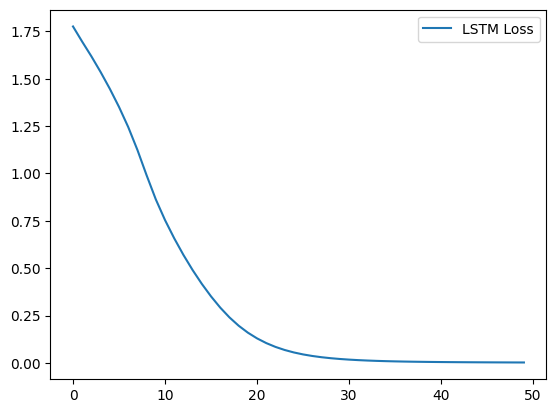

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- 1. 数据准备 (保持不变) ---
source_txt = 'abcdef'
words = source_txt[:-1] # abcde
pre_words = source_txt[1:] # bcdef
all_chars = words + pre_words

def build_dict(words):
    unique_chars = list(dict.fromkeys(words))
    return {char: idx for idx, char in enumerate(unique_chars)}

word_dict = build_dict(all_chars)
idx2char = {idx: char for char, idx in word_dict.items()}
input_size = len(word_dict) # 6
hidden_size = 8  
batch_size = 1
layer_num = 1

idx = [word_dict[char] for char in words]
pre_idx = [word_dict[char] for char in pre_words]

inputs = F.one_hot(torch.tensor(idx), num_classes=input_size).float().view(-1, batch_size, input_size)
print(inputs.shape) # (Seq, Batch, Input)

labels = torch.tensor(pre_idx).view(-1)
print(labels.shape) # (Seq,)    
# --- 2. 定义 LSTM 模型 (主要修改在这里) ---
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, batch_size, layer_num):
        super(LSTMPredictor, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.batch_size = batch_size
        self.layer_num = layer_num
        
        # LSTM
        self.lstm = nn.LSTM(input_size=self.input_size, hidden_size=self.hidden_size, num_layers=self.layer_num)
        
        # 加上全连接层，效果更好
        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self, input, hidden):
        #  LSTM 的输出 hidden 是一个元组 (h_n, c_n)
        # out: (Seq, Batch, Hidden)
        # hidden: ((Layer, Batch, Hidden), (Layer, Batch, Hidden))
        output, hidden = self.lstm(input, hidden)
        
        # 把 output 扔进全连接层变成分类概率
        # output.view(-1, ...) 把 (Seq, Batch) 拍扁
        final_out = self.fc(output.view(-1, self.hidden_size))
        
        return final_out, hidden

    def init_hidden(self):
        # 初始化必须返回两个由全0张量组成的元组 (h_0, c_0)
        h0 = torch.zeros(self.layer_num, self.batch_size, self.hidden_size)
        c0 = torch.zeros(self.layer_num, self.batch_size, self.hidden_size)
        return (h0, c0) # <--- 注意这里是元组

net = LSTMPredictor(input_size, hidden_size, batch_size, layer_num)

# --- 3. 训练循环  ---
optimizer = torch.optim.Adam(net.parameters(), lr=0.05)
criterion = nn.CrossEntropyLoss()

loss_history = []

print("开始 LSTM 训练...")
for epoch in range(50): # LSTM 
    optimizer.zero_grad()
    
    # 初始化拿到的是 (h0, c0)
    hidden = net.init_hidden()
    
    # 这里 hidden 自动在循环中传递，不用管它是 tensor 还是 tuple
    outputs, hidden = net(inputs, hidden)
    
    # 这里的 hidden 包含了梯度信息。
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch+1) % 10 == 0:
        _, predicted = outputs.max(dim=1)
        pred_str = ''.join([idx2char[i.item()] for i in predicted])
        print(f'Epoch {epoch+1} | Loss: {loss.item():.4f} | Pred: {pred_str}')

# 绘图
plt.plot(loss_history, label='LSTM Loss')
plt.legend()
plt.show()

In [50]:
print(f"{'层名称 (Name)':<20} | {'尺寸 (Shape)':<20} | {'参数个数 (Count)':<15}")
print("-" * 65)

total_params = 0
for name, param in net.named_parameters():
    # param.numel() 获取张量中元素的总个数 (number of elements)
    count = param.numel()
    total_params += count
    print(f"{name:<20} | {str(list(param.shape)):<20} | {count:<15}")

print("-" * 65)
print(f"总参数量 (Total Parameters): {total_params}")

层名称 (Name)           | 尺寸 (Shape)           | 参数个数 (Count)   
-----------------------------------------------------------------
lstm.weight_ih_l0    | [32, 6]              | 192            
lstm.weight_hh_l0    | [32, 8]              | 256            
lstm.bias_ih_l0      | [32]                 | 32             
lstm.bias_hh_l0      | [32]                 | 32             
fc.weight            | [6, 8]               | 48             
fc.bias              | [6]                  | 6              
-----------------------------------------------------------------
总参数量 (Total Parameters): 566


In [3]:
import torch
import torch.nn as nn

# === 设定输入 ===
# 假设 batch_size=1, input_size=2
x = torch.tensor([[2.0, 3.0]])

print(f"输入 x: {x}")
print("-" * 30)

# === 方式一：笨办法 (分开定义 4 个层) ===
# 为了模拟上面的数学例子，我手动指定权重
w_f = nn.Linear(2, 1, bias=False)
w_i = nn.Linear(2, 1, bias=False)
w_g = nn.Linear(2, 1, bias=False)
w_o = nn.Linear(2, 1, bias=False)

# 手动赋值权重 (注意 PyTorch 权重形状是 output x input)
with torch.no_grad():
    w_f.weight.copy_(torch.tensor([[1.0, 0.0]]))
    w_i.weight.copy_(torch.tensor([[0.0, 1.0]]))
    w_g.weight.copy_(torch.tensor([[1.0, 1.0]]))
    w_o.weight.copy_(torch.tensor([[2.0, 0.0]]))

# 分开计算 4 次
out_f = w_f(x)
out_i = w_i(x)
out_g = w_g(x)
out_o = w_o(x)

print("方式一 (分开算) 的结果:")
print(f"遗忘: {out_f.item()}, 输入: {out_i.item()}, 候选: {out_g.item()}, 输出: {out_o.item()}")

print("-" * 30)

# === 方式二：巧妙办法 (合并成 1 个层) ===
# 输出维度是 4 * 1 = 4
w_all = nn.Linear(2, 4, bias=False)

# 关键：把上面的 4 个权重拼起来！
with torch.no_grad():
    # cat 是拼接，dim=0 表示竖着拼
    combined_weight = torch.cat([
        w_f.weight,
        w_i.weight,
        w_g.weight,
        w_o.weight
    ], dim=0)
    print(combined_weight)
    w_all.weight.copy_(combined_weight)

# 只计算 1 次！
gates = w_all(x)

print("方式二 (合并算) 的结果 (Gates):")
print(gates)

# 验证切分
chunks = gates.chunk(4, dim=1)
print(f"切分后的第一部分: {chunks[0].item()}")

输入 x: tensor([[2., 3.]])
------------------------------
方式一 (分开算) 的结果:
遗忘: 2.0, 输入: 3.0, 候选: 5.0, 输出: 4.0
------------------------------
tensor([[1., 0.],
        [0., 1.],
        [1., 1.],
        [2., 0.]])
方式二 (合并算) 的结果 (Gates):
tensor([[2., 3., 5., 4.]], grad_fn=<MmBackward0>)
切分后的第一部分: 2.0
